In [31]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [20]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop5/adata_500k_residual.h5ad")

In [21]:
adata.obs.columns

Index(['experiment_number', 'replicate', 'date', 'cytometer',
       'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts',
       'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]',
       'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype',
       'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture',
       'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width',
       'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width',
       'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden'],
      dtype='object')

In [22]:
protocol_cols = ['tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]',
       'o2_[%]', 'days_of_culture']

protocol_cols_exp = protocol_cols + ['experiment_number']

In [25]:
prot_df = adata.obs.loc[:, protocol_cols_exp]

In [26]:
prot_df.loc[:, protocol_cols] = np.log1p(prot_df.loc[:, protocol_cols])

/tmp/ipykernel_2662979/1667148295.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2.89037176 2.89037176 2.89037176 ... 2.89037176 2.89037176 2.89037176]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  prot_df.loc[:, protocol_cols] = np.log1p(prot_df.loc[:, protocol_cols])


In [28]:
prot_df = prot_df.drop_duplicates()

In [67]:
import matplotlib.colors as mcolors
import re

def format_column_label(col):
    """
    Convert column names like 'il7_[ng_ml]' -> 'IL7 (ng/ml)'
    or 'days_of_culture' -> 'Days of culture'.
    """
    # Explicit overrides for names that need special casing
    overrides = {
        "tpo_[ng_ml]": "TPO (ng/ml)",
        "sr1_[nm]": "SR1 (nm)",
        "um171_[nm]": "UM171 (nm)",
        "um729_[µm]": "UM729 (µm)",
        "scf_[ng_ml]": "SCF (ng/ml)",
        "butyzamide_[nm]": "Butyzamide (nm)",
        "retinoic_acid_[µm]": "Retinoic acid (µm)",
        "ldl_[ng_ml]": "LDL (ng/ml)",
        "il3_[ng_ml]": "IL3 (ng/ml)",
        "il7_[ng_ml]": "IL7 (ng/ml)",
        "mcsf_[ng_ml]": "MCSF (ng/ml)",
        "ly_cocktail_[ul/well]": "Ly cocktail (µl/well)",
        "o2_[%]": "O2 (%)",
        "days_of_culture": "Days of culture",
        "experiment_number": "Experiment number",
    }
    if col in overrides:
        return overrides[col]

    # Generic fallback: name_[unit] -> Name (unit)
    match = re.match(r"^(.*)_\[(.*)\]$", col)
    if match:
        name, unit = match.groups()
        return f"{name.upper()} ({unit})"

    # Fallback: just replace underscores and capitalize
    return col.replace("_", " ").capitalize()


def plot_prot_barplot(prot_df, experiment_numbers, figsize=(14, 5), save_path=None):
    """
    Plot a grouped barplot of protocol columns for the given experiment numbers,
    colored using an interpolated red-to-blue palette.

    Parameters
    ----------
    prot_df : pd.DataFrame
        DataFrame with protocol/feature columns plus an 'experiment_number' column.
    experiment_numbers : list
        List of experiment numbers (as strings) to include in the plot.
    figsize : tuple, optional
        Figure size.
    save_path : str, optional
        If provided, saves the figure to this path.
    """
    experiment_numbers = [str(e) for e in experiment_numbers]

    # Filter to requested experiments
    sub_df = prot_df[prot_df["experiment_number"].astype(str).isin(experiment_numbers)].copy()
    sub_df["experiment_number"] = sub_df["experiment_number"].astype(str)

    # Identify value columns
    value_cols = [c for c in sub_df.columns if c != "experiment_number"]

    # Reshape to long format
    prot_long = sub_df.reset_index().melt(
        id_vars=["experiment_number"],
        value_vars=value_cols,
        var_name="column",
        value_name="value"
    )

    # Apply nicer axis labels to the column names
    prot_long["column"] = prot_long["column"].map(format_column_label)

    # --- Build interpolated palette from the reference colors ---
    hex_colors = ["#780000", "#870406", "#CD3E43", "#D76260", "#FDF0D5",
                  "#003049", "#144560", "#174864", "#245672", "#669BBC"]
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_palette", hex_colors)
    n = len(experiment_numbers)
    palette = [cmap(i / max(n - 1, 1)) for i in range(n)]

    sns.set_style("white")
    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=prot_long,
        x="column",
        y="value",
        hue="experiment_number",
        hue_order=experiment_numbers,
        palette=palette,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel("Value", fontsize=12)
    ax.tick_params(axis="x", rotation=90, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.legend(title="Experiment", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax

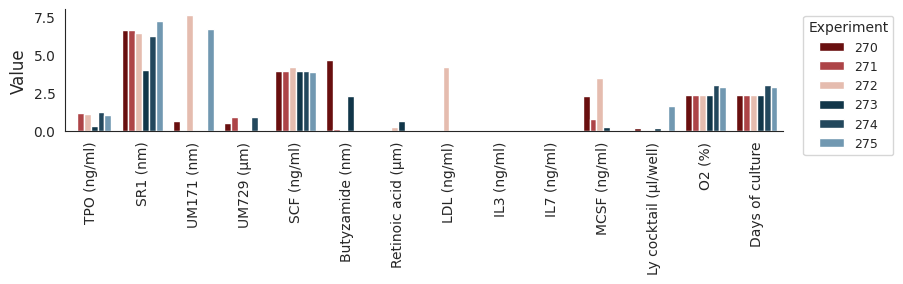

(<Figure size 900x300 with 1 Axes>, <Axes: ylabel='Value'>)

In [72]:
# with saving
plot_prot_barplot(prot_df, ["270", "271", "272", "273", "274", "275"], figsize=(9,3), save_path="protocols_mono_pro")

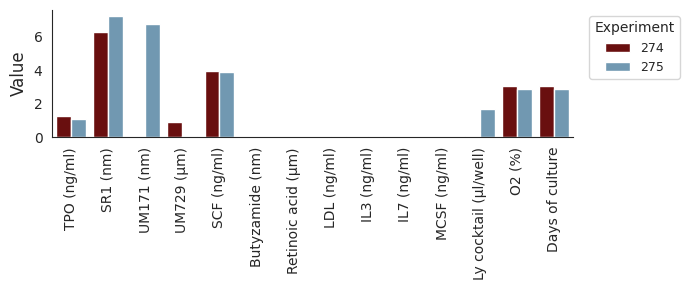

(<Figure size 700x300 with 1 Axes>, <Axes: ylabel='Value'>)

In [69]:
# with saving
plot_prot_barplot(prot_df, ["274", "275"],  figsize=(7,3), save_path="protocols_pro")

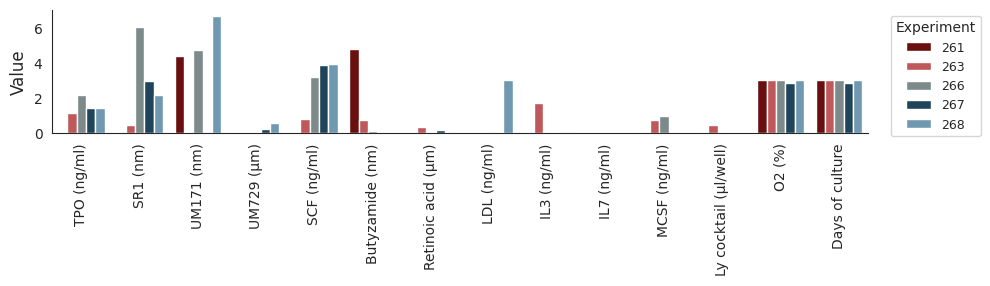

(<Figure size 1000x300 with 1 Axes>, <Axes: ylabel='Value'>)

In [70]:
# with saving
plot_prot_barplot(prot_df, ["261", "263", "266", "267", "268"], figsize=(10,3), save_path="protocols_traj")